<a href="https://colab.research.google.com/github/Magistrate-dot/ML-AI-project/blob/main/Minecraft_Mob_Detection_model_Comparison_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prep

In [2]:
!pip install -q ultralytics huggingface_hub scikit-learn
import os
import json
import shutil
from collections import defaultdict
from sklearn.model_selection import train_test_split

from huggingface_hub import snapshot_download
DATASET_PATH = "/content/minecraft_dataset"

repo_dir = snapshot_download(
    repo_id="twoturtles/minecraft-mobs",
    repo_type="dataset"
)

print(repo_dir)

for split in ["train", "valid"]:
    os.makedirs(f"{DATASET_PATH}/{split}/images", exist_ok=True)
    os.makedirs(f"{DATASET_PATH}/{split}/labels", exist_ok=True)

with open(os.path.join(repo_dir, "annotations.json"), "r") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]

annotations_by_image = defaultdict(list)

for ann in annotations:
    annotations_by_image[ann["image_id"]].append(ann)

train_images, valid_images = train_test_split(
    images,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("Training images:", len(train_images))
print("Validation images:", len(valid_images))

def process_split(image_list, split_name):

    for img in image_list:

        image_id = img["id"]
        filename = img["file_name"]

        src = os.path.join(repo_dir, "images", filename)
        dst = os.path.join(DATASET_PATH, split_name, "images", filename)

        shutil.copy(src, dst)

        label_file = os.path.join(
            DATASET_PATH,
            split_name,
            "labels",
            filename.replace(".png", ".txt")
        )

        with open(label_file, "w") as f:

            for ann in annotations_by_image.get(image_id, []):

                x, y, w, h = ann["bbox"]

                xc = (x + w / 2) / img["width"]
                yc = (y + h / 2) / img["height"]
                wn = w / img["width"]
                hn = h / img["height"]

                cls = ann["category_id"]

                f.write(
                    f"{cls} {xc} {yc} {wn} {hn}\n"
                )
process_split(train_images, "train")
process_split(valid_images, "valid")

yaml_text = f"""
path: {DATASET_PATH}

train: train/images
val: valid/images

names:
  0: chicken
  1: cow
  2: creeper
  3: enderman
  4: pig
  5: sheep
  6: skeleton
  7: spider
  8: zombie
"""

with open("data.yaml", "w") as f:
    f.write(yaml_text)

print("Train images:", len(os.listdir(f"{DATASET_PATH}/train/images")))
print("Train labels:", len(os.listdir(f"{DATASET_PATH}/train/labels")))

print("Validation images:", len(os.listdir(f"{DATASET_PATH}/valid/images")))
print("Validation labels:", len(os.listdir(f"{DATASET_PATH}/valid/labels")))



Fetching 411 files:   0%|          | 0/411 [00:00<?, ?it/s]

/root/.cache/huggingface/hub/datasets--twoturtles--minecraft-mobs/snapshots/a692d651805beaa37972f673ce93f4ef4b8c6394
Training images: 326
Validation images: 82
Train images: 326
Train labels: 326
Validation images: 82
Validation labels: 82


# Model

In [3]:
from ultralytics import YOLO

nano = YOLO("yolo11n.pt")
nano.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
)

small = YOLO("yolo11s.pt")
small.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f45ce434140>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

# Analytics

📦 Extracting metrics from the 50-epoch run folders...
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,907 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2258.2±825.6 MB/s, size: 216.6 KB)
val: Scanning /content/minecraft_dataset/valid/labels.cache... 82 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 22.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.2it/s 5.1s
                   all         82        104      0.951      0.933      0.979      0.795
               chicken         14         16      0.932      0.938      0.979      0.757
                   cow         10         12          1      0.938      0.995      0.804
               creeper          8          8      0.849          1      0.995      0.887
              enderman         10         10      0.934        0.9      0.9

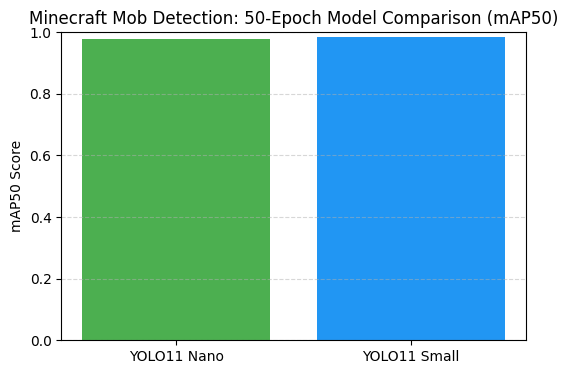

In [4]:
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt

print(" Extracting metrics from the 50-epoch run folders...")

# Point to the exact best weights generated by your latest run
nano_metrics = YOLO("/content/runs/detect/train/weights/best.pt").val(split="val")
small_metrics = YOLO("/content/runs/detect/train-2/weights/best.pt").val(split="val")

# Generate the data frame
comparison = pd.DataFrame({
    "Model": ["YOLO11 Nano", "YOLO11 Small"],
    "Precision": [nano_metrics.box.mp, small_metrics.box.mp],
    "Recall": [nano_metrics.box.mr, small_metrics.box.mr],
    "mAP50": [nano_metrics.box.map50, small_metrics.box.map50],
    "mAP50-95": [nano_metrics.box.map, small_metrics.box.map]
})

print("\n=== MODEL PERFORMANCE COMPARISON ===")
print(comparison)

# Save out to CSV for spreadsheet software
comparison.to_csv("final_50_epoch_comparison.csv", index=False)

# Plot the mAP50 performance side-by-side
plt.figure(figsize=(6, 4))
plt.bar(comparison["Model"], comparison["mAP50"], color=['#4CAF50', '#2196F3'])
plt.title("Minecraft Mob Detection: 50-Epoch Model Comparison (mAP50)")
plt.ylabel("mAP50 Score")
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Test

🧠 Loading your trained YOLO11 Small brain...
🔍 Analyzing 'Test_mob.jpg' for Minecraft mobs...

image 1/1 /content/Test_mob.jpg: 640x640 1 creeper, 15.5ms
Speed: 2.8ms preprocess, 15.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2

🎉 DETECTION COMPLETE! Here is what your AI found:


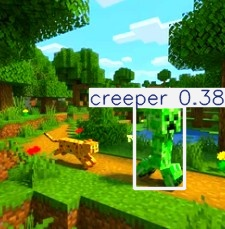

In [7]:
import os
from ultralytics import YOLO
from IPython.display import Image, display

# 1. Path to your uploaded JPG image inside the content folder
image_path = "/content/Test_mob.jpg"  # Changed extension to .jpg

# 2. Path to your 50-epoch Small model weights
model_path = "/content/runs/detect/train-2/weights/best.pt"

# Quick check to save you from errors
if not os.path.exists(image_path):
    print(f" Error: Could not find your image at {image_path}. Please make sure your file in the 'content' folder is named exactly 'test_mob.jpg'!")
elif not os.path.exists(model_path):
    print(f" Error: Could not find your model weights at {model_path}. Double-check your sidebar to see if the folder name is 'train' or 'train-2'.")
else:
    print(" Loading your trained YOLO11 Small brain...")
    model = YOLO(model_path)

    print(f" Analyzing '{os.path.basename(image_path)}' for Minecraft mobs...")
    # Run prediction and save visually
    results = model.predict(source=image_path, conf=0.25, save=True)

    # Grab the output paths dynamically
    saved_dir = results[0].save_dir
    base_name = os.path.basename(results[0].path)
    output_visual_path = os.path.join(saved_dir, base_name)

    print("\n🎉 DETECTION COMPLETE! Here is what your AI found:")
    display(Image(filename=output_visual_path))